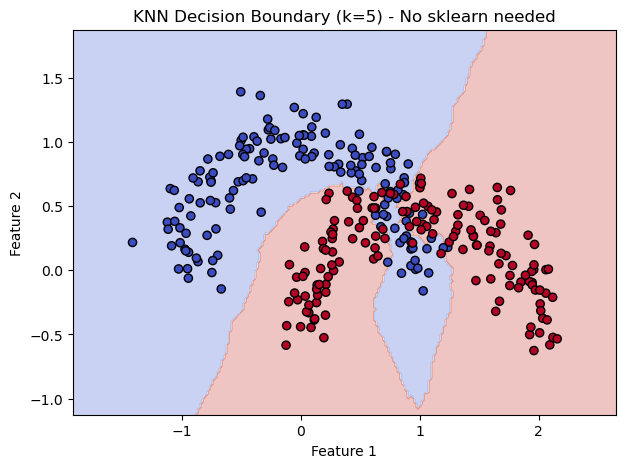

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 150
t = np.linspace(0, np.pi, n)
x0 = np.c_[np.cos(t), np.sin(t)] + np.random.normal(0, 0.15, (n,2))
x1 = np.c_[1 - np.cos(t), -0.5 + np.sin(t)] + np.random.normal(0, 0.15, (n,2))
X = np.vstack([x0, x1])
y = np.hstack([np.zeros(n), np.ones(n)])

def knn_predict(X_train, y_train, X_test, k=5):
    dists = np.sqrt(((X_test[:, None, :] - X_train[None, :, :])**2).sum(axis=2))
    nearest = np.argpartition(dists, k, axis=1)[:, :k]
    return (y_train[nearest].mean(axis=1) >= 0.5).astype(int)

k = 5
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn_predict(X, y, np.c_[xx.ravel(), yy.ravel()], k=k).reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolor='k', s=35)
plt.title(f'KNN Decision Boundary (k={k}) - No sklearn needed')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()